### Environment Setup & Styling

This cell initializes the workspace by importing core libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`) and machine learning utilities from `sklearn`. We also establish a global 'Teal & Coral' color palette and set a clean `whitegrid` theme for consistent visual storytelling across all plots.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set visualization parameters to match his aesthetic clean look
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Establish the color palette variables for instant global style management
colors = ['teal', 'coral']

print("✓ Core Data Science Environment Initialized Successfully.")

### Data Loading & Cleaning

Here we acquire the UCI Heart Disease dataset, with a fallback download mechanism for portability. The preprocessing steps include binarizing the target column (Healthy vs. Disease), imputing missing numeric values with the median, and handling categorical gaps with the mode to ensure a complete dataset for modeling.

In [13]:
import pandas as pd
import numpy as np
import os

# Opt-in to future behavior to silence downcasting warnings
pd.set_option('future.no_silent_downcasting', True)

# Fallback URL for the Heart Disease dataset from UCI repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

try:
    # Check if local file exists, otherwise download
    if os.path.exists('heart_disease_uci.csv'):
        df = pd.read_csv('heart_disease_uci.csv')
        print("✓ Local dataset loaded.")
    else:
        df = pd.read_csv(url, names=column_names, na_values='?')
        print("✓ Local file not found; dataset fetched from UCI repository.")

    # Handle target mapping
    target_column = 'num' if 'num' in df.columns else 'target'
    df[target_column] = np.where(df[target_column] > 0, 1, 0)

    # Impute missing values
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    df = df.infer_objects(copy=False)
    display(df.head())
except Exception as e:
    print(f"Error: {e}")

✓ Local dataset loaded.


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### Initial Data Profiling

This step provides a high-level summary of the dataset's architecture. We examine the total number of patient records (rows) and medical attributes (columns), while also inspecting the data types and checking for null values to verify the success of our previous cleaning step.

In [14]:
print("=== DATASET SHAPE ===")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}\n")

print("=== DATASET STRUCTURAL INFO ===")
df.info()

=== DATASET SHAPE ===
Rows: 920 | Columns: 16

=== DATASET STRUCTURAL INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    bool   
 8   restecg   920 non-null    object 
 9   thalch    920 non-null    float64
 10  exang     920 non-null    bool   
 11  oldpeak   920 non-null    float64
 12  slope     920 non-null    object 
 13  ca        920 non-null    float64
 14  thal      920 non-null    object 
 15  num       920 non-null    int64  
dtypes: bool(2), float64(5), int64(3), object(6)
memory usage: 102.6+ KB


### Target Variable Analysis

We isolate the target column to understand the class balance. By calculating the frequency of 'Healthy' vs. 'Disease' cases and visualizing them with a bar chart, we can determine if the model will need specific handling for class imbalance during training.

=== TARGET PROFILE DISTRIBUTION (num) ===
num
1    509
0    411
Name: count, dtype: int64


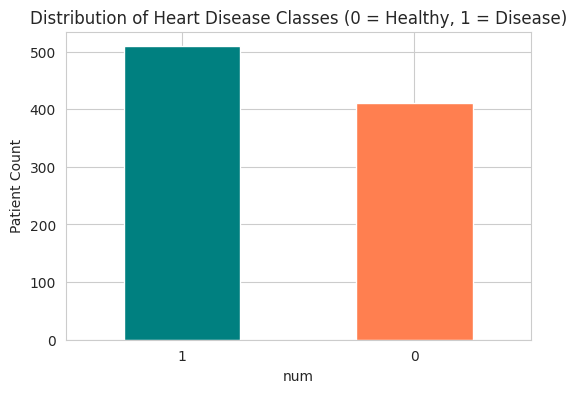

In [15]:
print(f"=== TARGET PROFILE DISTRIBUTION ({target_column}) ===")
print(df[target_column].value_counts())

# Target Distribution Plot
plt.figure(figsize=(6, 4))
df[target_column].value_counts().plot(kind="bar", color=colors)
plt.title("Distribution of Heart Disease Classes (0 = Healthy, 1 = Disease)")
plt.ylabel("Patient Count")
plt.xticks(rotation=0)
plt.show()

### Automated Feature Engineering

To optimize our visualization and modeling strategy, we use a heuristic approach to separate features. Variables with 10 or fewer unique values are categorized as discrete (categorical), while the rest are treated as continuous numeric metrics.

In [16]:
categorical_val = []
continuous_val = []

# Automated looping strategy exactly matching Fares' logic
for column in df.columns:
    if column == target_column:
        continue
    # If a column has 10 or fewer unique values, it acts as categorical
    if len(df[column].unique()) <= 10:
        categorical_val.append(column)
    else:
        continuous_val.append(column)

print("--- AUTOMATED FEATURE ARRAYS COMPLETED ---")
print(f"Categorical Features Detected ({len(categorical_val)}): {categorical_val}\n")
print(f"Continuous Features Detected ({len(continuous_val)}): {continuous_val}")

--- AUTOMATED FEATURE ARRAYS COMPLETED ---
Categorical Features Detected (9): ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Continuous Features Detected (6): ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak']


--- RESTRUCTURING COMPLETE: GENERATING DEMOGRAPHIC PLOTS ---


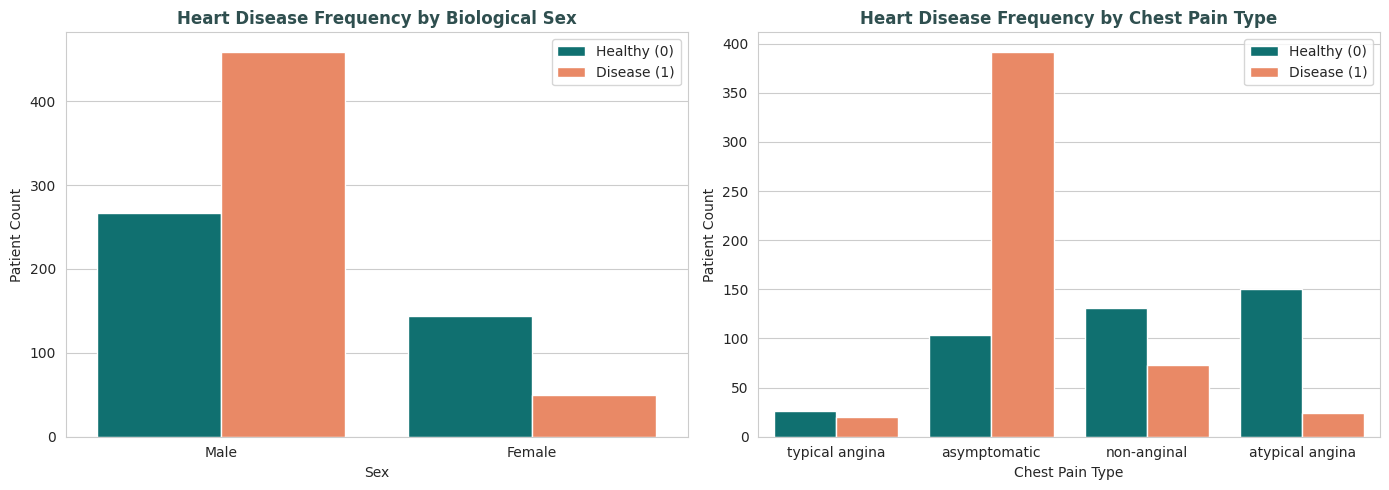

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- RESTRUCTURING COMPLETE: GENERATING DEMOGRAPHIC PLOTS ---")

if 'df' in locals():
    # Ensure colors are defined
    colors = ['teal', 'coral']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sex_col = 'sex' if 'sex' in df.columns else df.columns[1]
    sns.countplot(data=df, x=sex_col, hue=target_column, ax=axes[0], palette=colors)
    axes[0].set_title('Heart Disease Frequency by Biological Sex', fontweight='bold', color='darkslategray')
    axes[0].set_xlabel('Sex')
    axes[0].set_ylabel('Patient Count')
    axes[0].legend(['Healthy (0)', 'Disease (1)'])

    cp_column = 'cp'
    if cp_column in df.columns:
        sns.countplot(data=df, x=cp_column, hue=target_column, ax=axes[1], palette=colors)
        axes[1].set_title('Heart Disease Frequency by Chest Pain Type', fontweight='bold', color='darkslategray')
        axes[1].set_xlabel('Chest Pain Type')
        axes[1].set_ylabel('Patient Count')
        axes[1].legend(['Healthy (0)', 'Disease (1)'])

    plt.tight_layout()
    plt.show()
else:
    print("Error: DataFrame not found. Please run cell 2 first.")

### Clinical Indicator Visualization

This visualization focuses specifically on Fasting Blood Sugar (FBS). It helps us evaluate whether high blood sugar levels (above 120 mg/dl) correlate strongly with the presence of heart disease within this specific patient cohort.

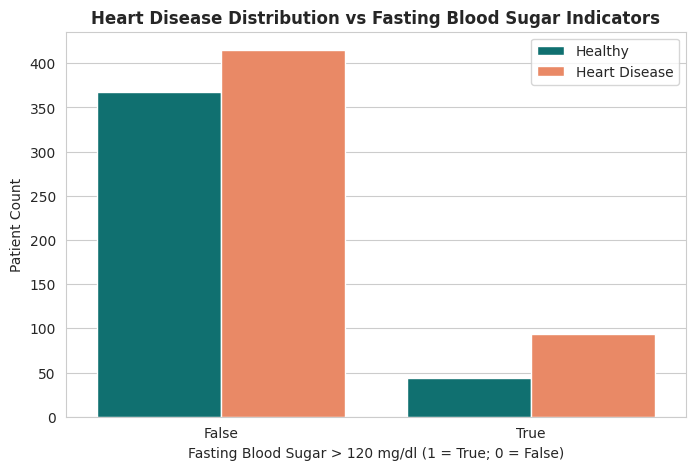

In [18]:
fbs_col = 'fbs' if 'fbs' in df.columns else [c for c in df.columns if 'sugar' in c.lower()][0]

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=fbs_col, hue=target_column, palette=colors)
plt.title("Heart Disease Distribution vs Fasting Blood Sugar Indicators", fontweight='bold')
plt.xlabel('Fasting Blood Sugar > 120 mg/dl (1 = True; 0 = False)')
plt.ylabel('Patient Count')
plt.legend(['Healthy', 'Heart Disease'])
plt.show()

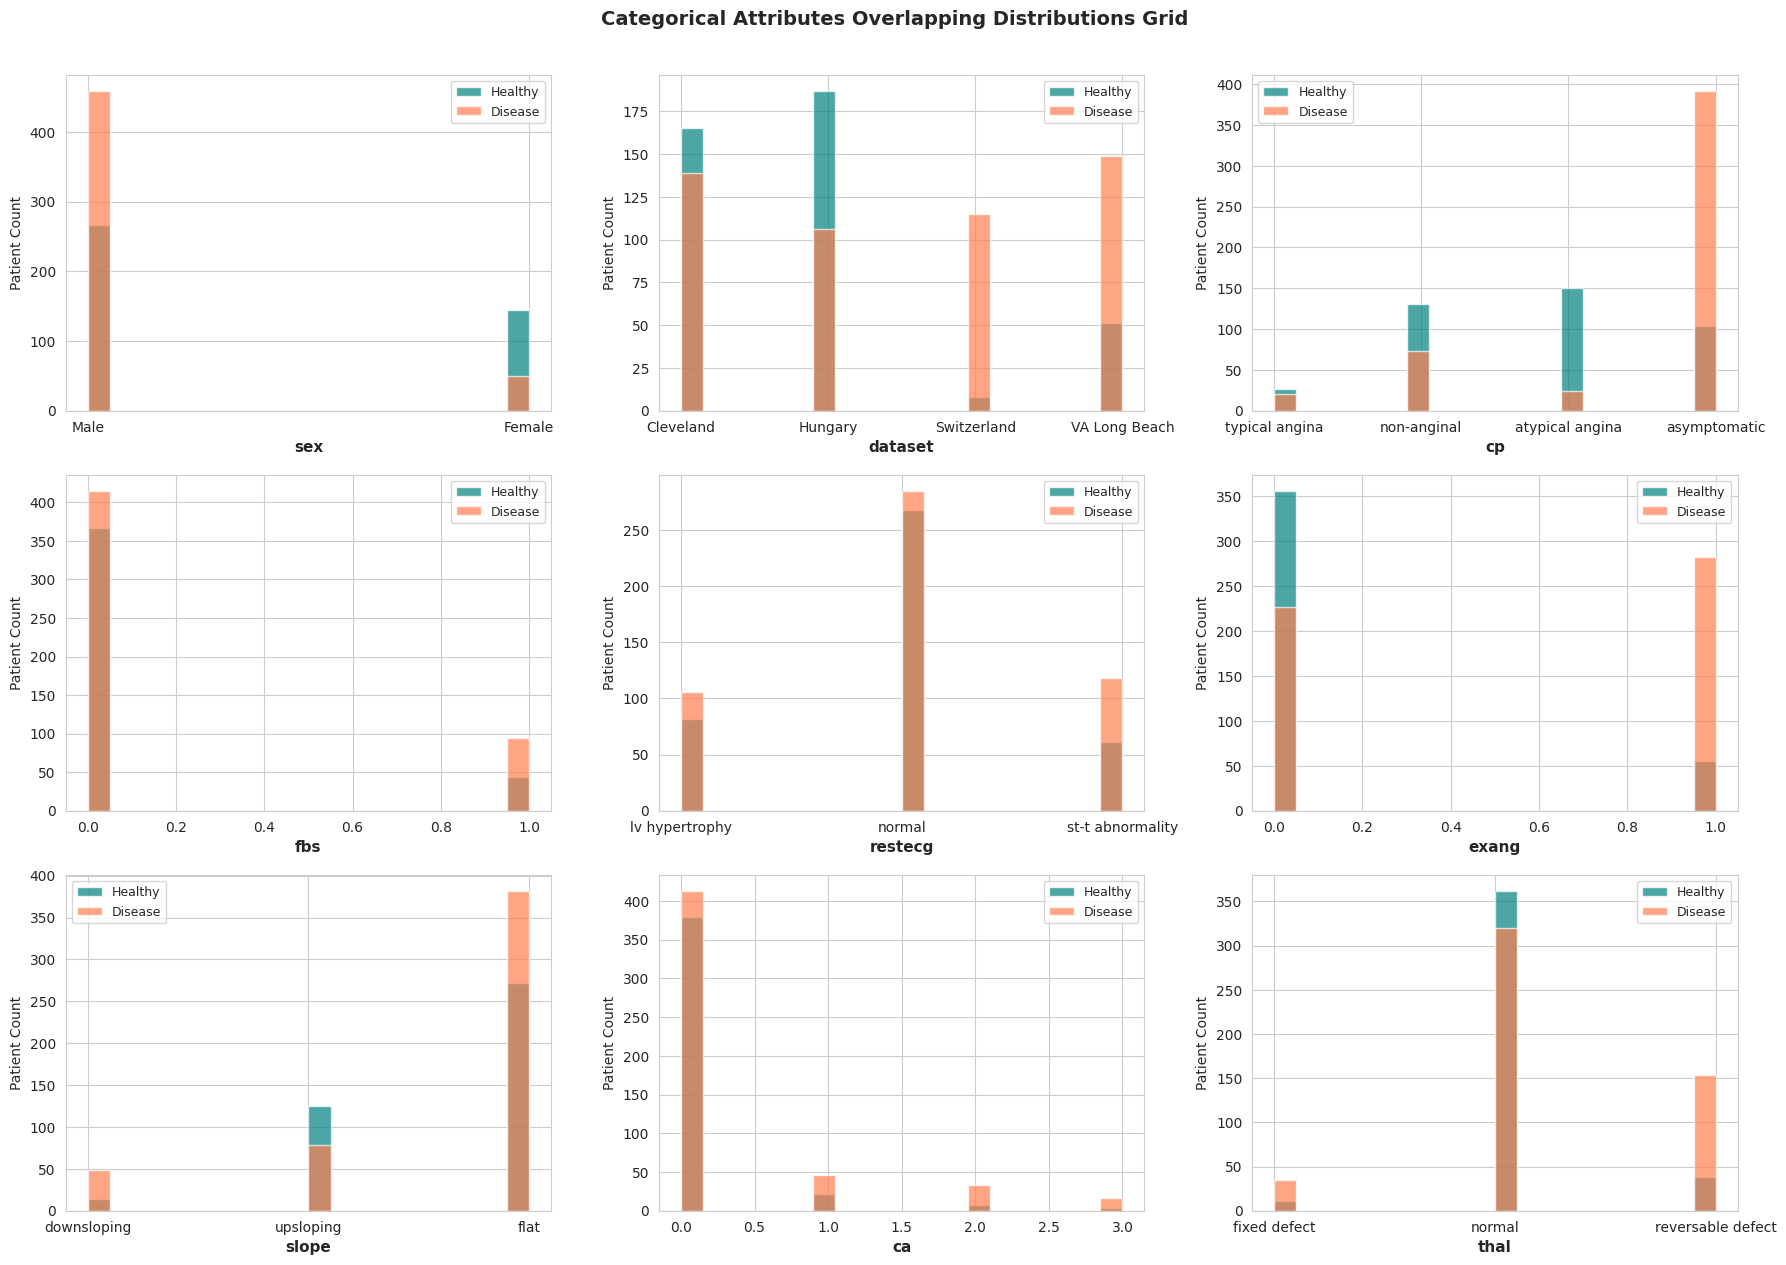

In [19]:
import matplotlib.pyplot as plt

# Ensure we have the required variables from preceding cells
if 'df' in locals() and 'categorical_val' in locals():
    plt.figure(figsize=(18, 16))
    for i, column in enumerate(categorical_val, 1):
        plt.subplot(4, 3, i)

        # Subset data for plotting
        healthy_data = df[df[target_column] == 0][column]
        disease_data = df[df[target_column] == 1][column]

        # Convert boolean to int to avoid histogram subtraction errors
        if healthy_data.dtype == 'bool':
            healthy_data = healthy_data.astype(int)
        if disease_data.dtype == 'bool':
            disease_data = disease_data.astype(int)

        healthy_data.hist(bins=20, color='teal', label='Healthy', alpha=0.7)
        disease_data.hist(bins=20, color='coral', label='Disease', alpha=0.7)
        plt.legend(fontsize=9)
        plt.xlabel(column, fontsize=11, fontweight='bold')
        plt.ylabel('Patient Count')

    plt.suptitle("Categorical Attributes Overlapping Distributions Grid", y=1.01, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    missing = []
    if 'df' not in locals(): missing.append('df (Cell 2)')
    if 'categorical_val' not in locals(): missing.append('categorical_val (Cell 5)')
    print(f"Error: Missing {', '.join(missing)}. Please run those cells first.")

### Numeric Distribution Analysis

We generate a grid of histograms for all continuous variables. By overlapping the distributions for healthy and diseased patients, we can visually identify which metrics (like age or cholesterol) show the most significant divergence between the two groups.

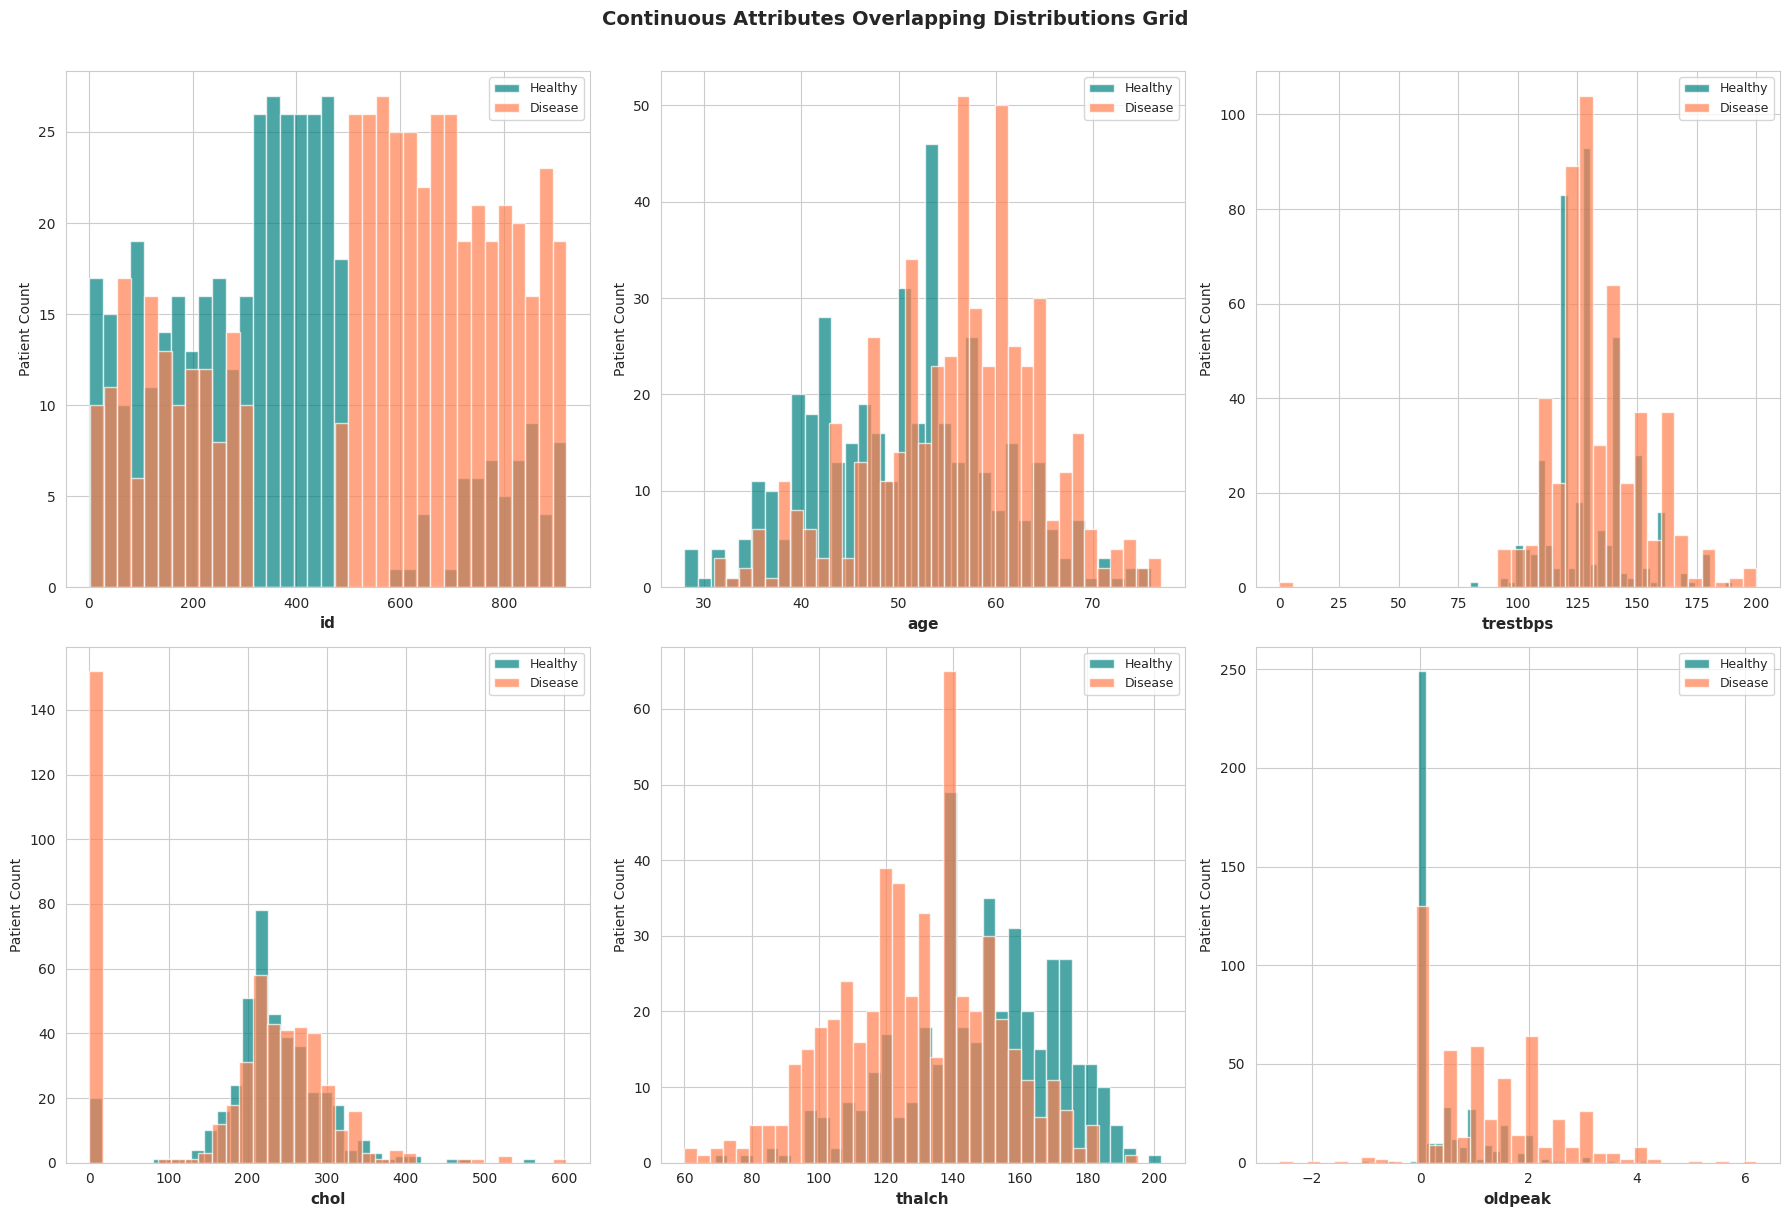

In [20]:
# Dynamic multi-grid tracking for continuous numeric metrics
plt.figure(figsize=(18, 12))

for i, column in enumerate(continuous_val, 1):
    plt.subplot(2, 3, i)
    df[df[target_column] == 0][column].hist(bins=35, color='teal', label='Healthy', alpha=0.7)
    df[df[target_column] == 1][column].hist(bins=35, color='coral', label='Disease', alpha=0.7)
    plt.legend(fontsize=9)
    plt.xlabel(column, fontsize=11, fontweight='bold')
    plt.ylabel('Patient Count')

plt.suptitle("Continuous Attributes Overlapping Distributions Grid", y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Matrix

The heatmap utilizes the 'mako' color profile to reveal linear relationships between numeric variables. This is crucial for identifying multicollinearity and understanding which features have the strongest positive or negative correlation with the target diagnostic.

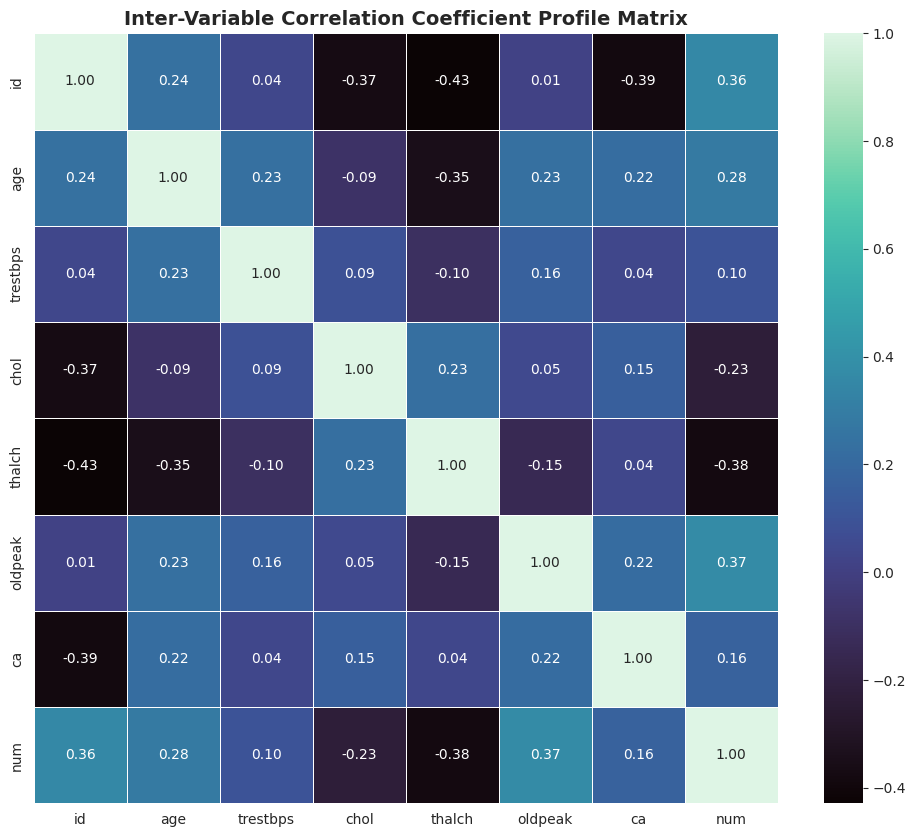

In [21]:
plt.figure(figsize=(12, 10))
numeric_only_df = df.select_dtypes(include=[np.number])

# Using "mako" for a clean, professional teal-to-black gradient profile
sns.heatmap(numeric_only_df.corr(), annot=True, fmt=".2f", cmap="mako", linewidths=0.5)
plt.title("Inter-Variable Correlation Coefficient Profile Matrix", fontsize=14, fontweight='bold')
plt.show()

### Data Partitioning and Encoding

Before training, we perform two critical tasks:
1. **One-Hot Encoding**: Converting categorical text data into numeric dummy variables.
2. **Stratified Splitting**: Dividing the data into 80% training and 20% testing sets while maintaining the original ratio of healthy-to-diseased cases.

In [22]:
print("--- PREPARING MODEL PIPELINE AND SPLITTING ARRAYS ---")

# Isolate feature vectors and execute hot encoding
X = df.drop(columns=[target_column])
y = df[target_column]
X_encoded = pd.get_dummies(X, drop_first=True)

print("--- MATRIX DIMENSIONALITY SYNCED ---")
print(f"Initial variables shape: {X.shape} -> Post Dummy Encoding shape: {X_encoded.shape}\n")

# 80/20 Stratified data split processing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train Records Array: {X_train.shape[0]} samples")
print(f"Test Records Array: {X_test.shape[0]} samples")

--- PREPARING MODEL PIPELINE AND SPLITTING ARRAYS ---
--- MATRIX DIMENSIONALITY SYNCED ---
Initial variables shape: (920, 15) -> Post Dummy Encoding shape: (920, 22)

Train Records Array: 736 samples
Test Records Array: 184 samples


### Model Training and Diagnostic Evaluation

We initialize a Random Forest Classifier to serve as our primary diagnostic engine. Post-training, we evaluate its performance using a Confusion Matrix, Precision, and Recall scores to see how many false positives or false negatives the model produces.

✓ Random Forest Classification Engine compiled and trained successfully.

Train Result:
Accuracy Score: 100.00%
_______________________________________________
CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       329
           1       1.00      1.00      1.00       407

    accuracy                           1.00       736
   macro avg       1.00      1.00      1.00       736
weighted avg       1.00      1.00      1.00       736



Test Result:
Accuracy Score: 86.96%
_______________________________________________
CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       0.89      0.80      0.85        82
           1       0.85      0.92      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



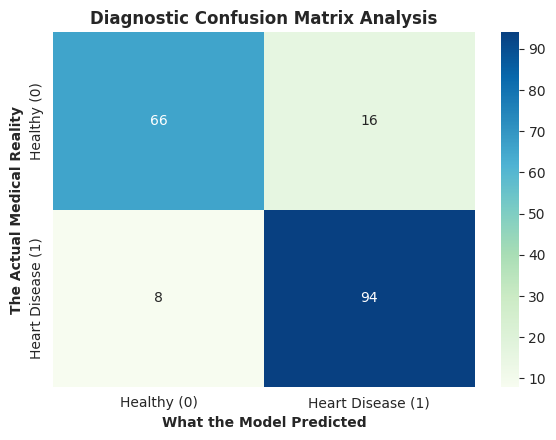

In [23]:
# Run classification engine setup
heart_model = RandomForestClassifier(n_estimators=100, random_state=42)
heart_model.fit(X_train, y_train)

print("✓ Random Forest Classification Engine compiled and trained successfully.\n")

# Predict across both sets to confirm variance logs matching his logs layout
y_train_pred = heart_model.predict(X_train)
y_test_pred = heart_model.predict(X_test)

print("Train Result:\n================================================")
print(f"Accuracy Score: {accuracy_score(y_train, y_train_pred) * 100:.2f}%")
print("_______________________________________________")
print("CLASSIFICATION REPORT:\n", classification_report(y_train, y_train_pred))

print("\n\nTest Result:\n================================================")
print(f"Accuracy Score: {accuracy_score(y_test, y_test_pred) * 100:.2f}%")
print("_______________________________________________")
print("CLASSIFICATION REPORT:\n", classification_report(y_test, y_test_pred))

# Generate final validation matrix visual
plt.figure(figsize=(6, 4.5))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='GnBu',
            xticklabels=['Healthy (0)', 'Heart Disease (1)'],
            yticklabels=['Healthy (0)', 'Heart Disease (1)'])

plt.xlabel('What the Model Predicted', fontweight='bold')
plt.ylabel('The Actual Medical Reality', fontweight='bold')
plt.title('Diagnostic Confusion Matrix Analysis', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### Algorithmic Benchmarking

To ensure we are using the most effective tool, we compare the Random Forest against Logistic Regression and K-Nearest Neighbors. We use a Pipeline to scale the data appropriately for the distance-based algorithms, ensuring a fair comparison.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

print("--- TRAINING MULTIPLE ALGORITHMS FOR COMPARISON ---")

# 1. Initialize dictionaries to hold our models and their results
models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    'K-Nearest Neighbors': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

accuracies = {}

# 2. Loop through, train, and score each model
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    score = accuracy_score(y_test, predictions) * 100
    accuracies[name] = score
    print(f"✓ {name} achieved a Test Accuracy of: {score:.2f}%")

--- TRAINING MULTIPLE ALGORITHMS FOR COMPARISON ---
✓ Logistic Regression achieved a Test Accuracy of: 86.96%
✓ K-Nearest Neighbors achieved a Test Accuracy of: 86.41%
✓ Random Forest achieved a Test Accuracy of: 86.96%


--- GENERATING ACCURACY SCOREBOARD ---


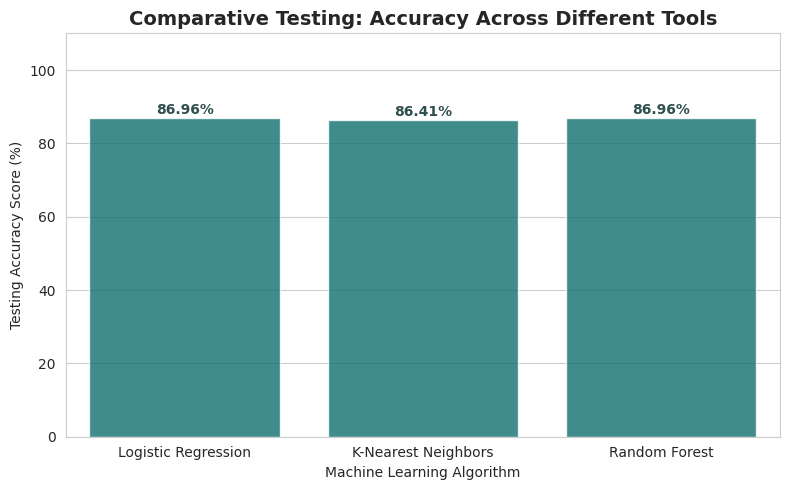

In [26]:
print("--- GENERATING ACCURACY SCOREBOARD ---")

# Plotting a clean summary bar chart using your Teal theme color
plt.figure(figsize=(8, 5))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), color='teal', alpha=0.8)

# Add value labels on top of each bar
for i, val in enumerate(accuracies.values()):
    plt.text(i, val + 1, f"{val:.2f}%", ha='center', fontweight='bold', color='darkslategray')

plt.title("Comparative Testing: Accuracy Across Different Tools", fontweight='bold', fontsize=14)
plt.ylabel("Testing Accuracy Score (%)")
plt.xlabel("Machine Learning Algorithm")
plt.ylim(0, 110) # Gives breathing room for the text labels
plt.tight_layout()
plt.show()